# Market State Vector (m_t) Feature Engineering

This notebook builds the market state vector per CLAUDE.md specification:
- Sentiment: CNN Fear & Greed Index
- Volatility: VIX, EGARCH features
- Trend/Regime: SPX momentum, drawdown, distance to MA
- Liquidity: Credit spreads, yield curve
- Breadth: Market participation metrics

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## 1. Load CNN Fear & Greed Index

In [2]:
# Load Fear & Greed data
fng = pd.read_csv('data/all_fng_csv_13_feb_2026.csv', parse_dates=['Date'])
fng = fng.rename(columns={'Date': 'date', 'Fear Greed': 'fear_greed'})
fng = fng.set_index('date').sort_index()

# Remove rows where fear_greed is 0 (weekends)
rows_before = len(fng)
fng = fng[fng['fear_greed'] != 0]
rows_after = len(fng)
print(f"Removed {rows_before - rows_after} rows with fear_greed=0 (weekends)")

print(f"Fear & Greed data: {fng.index.min()} to {fng.index.max()}")
print(f"Shape: {fng.shape}")
fng.head()

Removed 1701 rows with fear_greed=0 (weekends)
Fear & Greed data: 2011-01-03 00:00:00 to 2026-02-13 00:00:00
Shape: (3820, 1)


,fear_greed
date,
2011-01-03,68.0
2011-01-04,68.0
2011-01-05,67.0
2011-01-06,64.0
2011-01-07,63.0


## 1b. Fear & Greed Feature Expansion (Trend + Volatility)

In [3]:
# ============= Helper Functions (from feature_engineering.ipynb) =============

def ema(series: pd.Series, span: int) -> pd.Series:
    """Exponential moving average."""
    return series.ewm(span=span, adjust=False).mean()


def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """
    Relative Strength Index (Wilder's smoothing).
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()

    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def macd(series: pd.Series,
         fast: int = 12,
         slow: int = 26,
         signal: int = 9) -> pd.DataFrame:
    """
    MACD line, signal line, and histogram.
    """
    ema_fast = ema(series, fast)
    ema_slow = ema(series, slow)
    macd_line = ema_fast - ema_slow
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line

    return pd.DataFrame({
        "macd": macd_line,
        "macd_signal": signal_line,
        "macd_hist": hist
    })


def roc(series: pd.Series, period: int = 10) -> pd.Series:
    """
    Rate of Change: (price_t / price_{t-k}) - 1.
    """
    return series / series.shift(period) - 1

def obv(close: pd.Series, volume: pd.Series) -> pd.Series:
    """
    On-Balance Volume.
    """
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()

def stoch_k(high: pd.Series, low: pd.Series, close: pd.Series, window: int = 14) -> pd.Series:
    """
    Stochastic %K: measures where close is relative to the high-low range over a period.
    %K = 100 * (Close - Lowest Low) / (Highest High - Lowest Low)
    Already scale-invariant (0-100 range).
    """
    lowest_low = low.rolling(window=window, min_periods=1).min()
    highest_high = high.rolling(window=window, min_periods=1).max()
    
    k = 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-10)
    return k


def stoch_d(high: pd.Series, low: pd.Series, close: pd.Series, 
            k_window: int = 14, d_window: int = 3) -> pd.Series:
    """
    Stochastic %D: smoothed moving average of %K.
    %D = SMA(%K, d_window)
    Already scale-invariant (0-100 range).
    """
    k = stoch_k(high, low, close, window=k_window)
    d = k.rolling(window=d_window, min_periods=1).mean()
    return d

def mfm(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    """
    Money Flow Multiplier.
    MFM = ((Close - Low) - (High - Close)) / (High - Low)
    Scale-invariant: always between -1 and +1.
    +1 = close at high (strong buying pressure)
    -1 = close at low (strong selling pressure)
    0 = close at midpoint
    """
    return ((close - low) - (high - close)) / (high - low + 1e-10)


def ad_oscillator(high: pd.Series, low: pd.Series, close: pd.Series, volume: pd.Series) -> pd.Series:
    """
    Accumulation/Distribution Oscillator (Chaikin A/D Line).
    AD = cumsum( ((Close - Low) - (High - Close)) / (High - Low) * Volume )
    
    The Money Flow Multiplier ((Close - Low) - (High - Close)) / (High - Low) is scale-invariant (-1 to +1).
    But cumulative AD is not scale-invariant, so we return pct_change for features.
    """
    # Money Flow Multiplier: already scale-invariant (-1 to +1)
    money_flow_mult = mfm(high, low, close)
    
    # Money Flow Volume
    mfv = money_flow_mult * volume
    
    # Cumulative A/D Line
    ad_line = mfv.cumsum()
    
    return ad_line

In [4]:
# ============= Trend Features for Fear & Greed (adapted from trend_ft) =============
# Excludes features requiring High/Low prices

def fng_trend_ft(df, col='fear_greed'):
    """Apply trend features to a single-column series (Fear & Greed).
    Matches trend_ft from feature_engineering.ipynb, adapted for single series.
    """
    df = df.copy()
    series = df[col]
    
    # EMAs at multiple timescales
    for span in [3, 5, 10, 21, 63, 126]:
        df[f"fng_ema_{span}"] = ema(series, span)
    
    # Distance to EMA (percentage only - more stationary)
    for span in [3, 5, 10, 21, 63, 126]:
        df[f"fng_dist_to_ema_{span}_pct"] = (series - df[f"fng_ema_{span}"]) / df[f"fng_ema_{span}"]
    
    # EMA crossover indicators (shorter EMA above longer EMA)
    # Short-term crossovers
    df["fng_ema3_above_ema5"] = (df["fng_ema_3"] - df["fng_ema_5"]) / df["fng_ema_5"]
    df["fng_ema3_above_ema10"] = (df["fng_ema_3"] - df["fng_ema_10"]) / df["fng_ema_10"]
    df["fng_ema5_above_ema10"] = (df["fng_ema_5"] - df["fng_ema_10"]) / df["fng_ema_10"]
    df["fng_ema5_above_ema21"] = (df["fng_ema_5"] - df["fng_ema_21"]) / df["fng_ema_21"]
    df["fng_ema5_above_ema63"] = (df["fng_ema_5"] - df["fng_ema_63"]) / df["fng_ema_63"]
    # Medium-term crossovers
    df["fng_ema10_above_ema21"] = (df["fng_ema_10"] - df["fng_ema_21"]) / df["fng_ema_21"]
    df["fng_ema10_above_ema63"] = (df["fng_ema_10"] - df["fng_ema_63"]) / df["fng_ema_63"]
    df["fng_ema21_above_ema63"] = (df["fng_ema_21"] - df["fng_ema_63"]) / df["fng_ema_63"]
    df["fng_ema21_above_ema126"] = (df["fng_ema_21"] - df["fng_ema_126"]) / df["fng_ema_126"]
    # Long-term crossover (golden/death cross equivalent)
    df["fng_ema63_above_ema126"] = (df["fng_ema_63"] - df["fng_ema_126"]) / df["fng_ema_126"]
    
    # MACD - Fast (1 week to 3 weeks)
    macd_fast = macd(series, fast=5, slow=15, signal=5)
    macd_fast.columns = ["fng_macd_fast", "fng_macd_signal_fast", "fng_macd_hist_fast"]
    df = pd.concat([df, macd_fast], axis=1)
    # MACD as % of value (scale-invariant)
    df["fng_macd_fast_pct"] = df["fng_macd_fast"] / series
    df["fng_macd_signal_fast_pct"] = df["fng_macd_signal_fast"] / series
    df["fng_macd_hist_fast_pct"] = df["fng_macd_hist_fast"] / series
    # MACD diff changes
    df["fng_macd_fast_change"] = df["fng_macd_fast"].diff()
    df["fng_macd_hist_fast_change"] = df["fng_macd_hist_fast"].diff()
    
    # MACD - Standard (2 weeks to 1 month)
    macd_std = macd(series, fast=12, slow=26, signal=9)
    macd_std.columns = ["fng_macd_std", "fng_macd_signal_std", "fng_macd_hist_std"]
    df = pd.concat([df, macd_std], axis=1)
    # MACD as % of value (scale-invariant)
    df["fng_macd_std_pct"] = df["fng_macd_std"] / series
    df["fng_macd_signal_std_pct"] = df["fng_macd_signal_std"] / series
    df["fng_macd_hist_std_pct"] = df["fng_macd_hist_std"] / series
    # MACD diff changes
    df["fng_macd_std_change"] = df["fng_macd_std"].diff()
    df["fng_macd_hist_std_change"] = df["fng_macd_hist_std"].diff()
    
    # MACD - Slow (1 month to 3 months)
    macd_slow = macd(series, fast=21, slow=63, signal=15)
    macd_slow.columns = ["fng_macd_slow", "fng_macd_signal_slow", "fng_macd_hist_slow"]
    df = pd.concat([df, macd_slow], axis=1)
    # MACD as % of value (scale-invariant)
    df["fng_macd_slow_pct"] = df["fng_macd_slow"] / series
    df["fng_macd_signal_slow_pct"] = df["fng_macd_signal_slow"] / series
    df["fng_macd_hist_slow_pct"] = df["fng_macd_hist_slow"] / series
    # MACD diff changes
    df["fng_macd_slow_change"] = df["fng_macd_slow"].diff()
    df["fng_macd_hist_slow_change"] = df["fng_macd_hist_slow"].diff()
    
    # RSI - Multiple windows to capture momentum at different timescales
    for window in [5, 10, 21, 63]:
        df[f"fng_rsi_{window}"] = rsi(series, window=window)
        df[f"fng_rsi_{window}_change"] = df[f"fng_rsi_{window}"].diff()
    
    # Raw diff - Multiple periods (replaces ROC)
    # Fear & Greed is already 0-100 standardized, so raw diff is more appropriate
    # than ROC which blows up at low values (e.g., 10->20 = +100% ROC)
    for period in [1, 5, 10, 21, 63]:
        df[f"fng_diff_{period}"] = series.diff(period)
    
    return df

In [5]:
# ============= Volatility Features for Fear & Greed (adapted from volatility_ft) =============
# Excludes features requiring High/Low prices (ATR, Parkinson vol)

def fng_volatility_ft(df, col='fear_greed'):
    """Apply volatility features to a single-column series (Fear & Greed).
    Matches volatility_ft from feature_engineering.ipynb, excluding High/Low features.
    """
    df = df.copy()
    series = df[col]
    
    # Use diff-based volatility (not log returns) since FNG is already 0-100 standardized
    # Log returns don't make sense for a bounded index (e.g., log(50/45) is meaningless)
    diffs = series.diff()
    
    # Rolling std of diffs
    for wnd in [3, 5, 10, 21, 63]:
        df[f"fng_vol_std_{wnd}"] = diffs.rolling(window=wnd, min_periods=1).std()
    
    # Z-scores of volatility (regime detection)
    for wnd in [10, 21, 63]:
        mu = df[f"fng_vol_std_{wnd}"].rolling(126, min_periods=63).mean()
        sd = df[f"fng_vol_std_{wnd}"].rolling(126, min_periods=63).std()
        df[f"fng_vol_std_zscore_{wnd}"] = (df[f"fng_vol_std_{wnd}"] - mu) / (sd + 1e-10)
    
    # Bollinger Bands - multiple windows with % distance metrics
    for wnd in [3, 5, 10, 21, 63]:
        # Calculate SMA and standard deviation
        sma = series.rolling(window=wnd, min_periods=1).mean()
        std = series.rolling(window=wnd, min_periods=1).std()
        
        # Bollinger Bands (2 standard deviations)
        upper_band = sma + (2 * std)
        lower_band = sma - (2 * std)
        
        # % distance from bands (scale-invariant)
        df[f"fng_bb_{wnd}_pct_from_upper"] = (series - upper_band) / series
        df[f"fng_bb_{wnd}_pct_from_lower"] = (series - lower_band) / series
    
    return df

In [6]:
# ============= Apply Feature Expansion to Fear & Greed =============
# Apply trend and volatility features
fng_expanded = fng_trend_ft(fng)
fng_expanded = fng_volatility_ft(fng_expanded)

# Drop intermediate EMA columns (keep the features derived from them)
ema_cols_to_drop = [c for c in fng_expanded.columns if c.startswith('fng_ema_') and '_above_' not in c and '_dist_' not in c]
fng_expanded = fng_expanded.drop(columns=ema_cols_to_drop)

# Drop raw MACD columns (keep the _pct and _change versions)
macd_cols_to_drop = [c for c in fng_expanded.columns if c.startswith('fng_macd_') and '_pct' not in c and '_change' not in c]
fng_expanded = fng_expanded.drop(columns=macd_cols_to_drop)

# Quintile one-hot encoding for regime detection
# Bins: 0-20 (Extreme Fear), 20-40 (Fear), 40-60 (Neutral), 60-80 (Greed), 80-100 (Extreme Greed)
# Q1 (Extreme Fear) is the reference category (dropped)
quintile = pd.cut(fng_expanded['fear_greed'], bins=[0, 20, 40, 60, 80, 100], 
                  labels=['q1_extreme_fear', 'q2_fear', 'q3_neutral', 'q4_greed', 'q5_extreme_greed'],
                  include_lowest=True)
quintile_dummies = pd.get_dummies(quintile, prefix='fng', dtype=int)
quintile_dummies = quintile_dummies.drop(columns=['fng_q1_extreme_fear'])  # Drop reference category
fng_expanded = pd.concat([fng_expanded, quintile_dummies], axis=1)

print(f"Fear & Greed expanded shape: {fng_expanded.shape}")
print(f"New features added: {len(fng_expanded.columns) - 1}")  # -1 for original fear_greed
print(f"\nFeature columns:")
print(fng_expanded.columns.tolist())

Fear & Greed expanded shape: (3820, 67)
New features added: 66

Feature columns:
['fear_greed', 'fng_dist_to_ema_3_pct', 'fng_dist_to_ema_5_pct', 'fng_dist_to_ema_10_pct', 'fng_dist_to_ema_21_pct', 'fng_dist_to_ema_63_pct', 'fng_dist_to_ema_126_pct', 'fng_ema3_above_ema5', 'fng_ema3_above_ema10', 'fng_ema5_above_ema10', 'fng_ema5_above_ema21', 'fng_ema5_above_ema63', 'fng_ema10_above_ema21', 'fng_ema10_above_ema63', 'fng_ema21_above_ema63', 'fng_ema21_above_ema126', 'fng_ema63_above_ema126', 'fng_macd_fast_pct', 'fng_macd_signal_fast_pct', 'fng_macd_hist_fast_pct', 'fng_macd_fast_change', 'fng_macd_hist_fast_change', 'fng_macd_std_pct', 'fng_macd_signal_std_pct', 'fng_macd_hist_std_pct', 'fng_macd_std_change', 'fng_macd_hist_std_change', 'fng_macd_slow_pct', 'fng_macd_signal_slow_pct', 'fng_macd_hist_slow_pct', 'fng_macd_slow_change', 'fng_macd_hist_slow_change', 'fng_rsi_5', 'fng_rsi_5_change', 'fng_rsi_10', 'fng_rsi_10_change', 'fng_rsi_21', 'fng_rsi_21_change', 'fng_rsi_63', 'fng_rs

## 2. Pull Market Data from yfinance

In [7]:
# Define date range based on Fear & Greed data
start_date = fng.index.min().strftime('%Y-%m-%d')
# Add 1 day to end_date because yfinance's end parameter is exclusive
end_date = (fng.index.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

# Tickers to pull - expanded for new features
tickers = {
    # Core market
    '^GSPC': 'spx',      # S&P 500
    '^VIX': 'vix',       # VIX
    'SPY': 'spy',        # SPY for liquidity/volume
    
    # Treasury Yields (for multiple yield curve spreads)
    '^IRX': 'irx',       # 3-Month Treasury
    '^FVX': 'fvx',       # 5-Year Treasury
    '^TNX': 'tnx',       # 10-Year Treasury
    '^TYX': 'tyx',       # 30-Year Treasury
    
    # Cross-asset
    'TLT': 'tlt',        # Long-term treasuries
    'GLD': 'gld',        # Gold
    
    # Credit & Real Rates (per CLAUDE.md)
    'HYG': 'hyg',        # High-yield corporate bonds (for credit spread)
    'TIP': 'tip',        # TIPS (for real rates)
    
    # Equal-weight vs cap-weight
    'RSP': 'rsp',        # Equal-weight S&P 500
    
    # Sector ETFs for cyclical vs defensive
    'XLK': 'xlk',        # Technology (cyclical)
    'XLY': 'xly',        # Consumer Discretionary (cyclical)
    'XLI': 'xli',        # Industrials (cyclical)
    'XLU': 'xlu',        # Utilities (defensive)
    'XLV': 'xlv',        # Healthcare (defensive)
}

print(f"Pulling data from {start_date} to {end_date}")

Pulling data from 2011-01-03 to 2026-02-14


In [8]:
# Pull all market data
market_data = {}
for ticker, name in tickers.items():
    print(f"Downloading {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    market_data[name] = df
    print(f"  Got {len(df)} rows")

  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3801 rows
  Got 3801 rows
  Got 3801 rows
  Got 3801 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows
  Got 3802 rows


In [9]:
# Build unified market dataframe
market = pd.DataFrame(index=market_data['spx'].index)

# S&P 500 price and returns
market['spx_close'] = market_data['spx']['Close']
market['spx_return'] = market_data['spx']['Close'].pct_change() * 100  # in %

# VIX
market['vix'] = market_data['vix']['Close']

# Treasury yields (for yield curve spreads)
market['irx'] = market_data['irx']['Close']  # 3M yield
market['fvx'] = market_data['fvx']['Close']  # 5Y yield
market['tnx'] = market_data['tnx']['Close']  # 10Y yield
market['tyx'] = market_data['tyx']['Close']  # 30Y yield

# SPY (for volume features)
market['spy_close'] = market_data['spy']['Close']
market['spy_high'] = market_data['spy']['High']
market['spy_low'] = market_data['spy']['Low']
market['spy_volume'] = market_data['spy']['Volume']

# Cross-asset ETFs
market['tlt_close'] = market_data['tlt']['Close']
market['gld_close'] = market_data['gld']['Close']

# Credit & Real Rates ETFs
market['hyg_close'] = market_data['hyg']['Close']
market['tip_close'] = market_data['tip']['Close']

# Equal-weight S&P
market['rsp_close'] = market_data['rsp']['Close']

# Sector ETFs
market['xlk_close'] = market_data['xlk']['Close']
market['xly_close'] = market_data['xly']['Close']
market['xli_close'] = market_data['xli']['Close']
market['xlu_close'] = market_data['xlu']['Close']
market['xlv_close'] = market_data['xlv']['Close']

market = market.dropna()
print(f"Market data shape: {market.shape}")
market.head()

Market data shape: (3800, 21)


,spx_close,spx_return,vix,irx,fvx,tnx,tyx,spy_close,spy_high,spy_low,...,tlt_close,gld_close,hyg_close,tip_close,rsp_close,xlk_close,xly_close,xli_close,xlu_close,xlv_close
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-04,1270.199951,-0.131306,17.379999,0.135,2.017,3.346,4.437,97.139313,97.437661,96.534964,...,61.101669,134.750000,38.985847,73.364243,37.114353,10.463101,15.695752,26.467825,9.495085,24.755781
2011-01-05,1276.560059,0.500717,17.020000,0.135,2.158,3.483,4.551,97.644234,97.705435,96.741537,...,59.755764,134.369995,39.084629,73.084007,37.309456,10.524485,15.825033,26.603680,9.435062,24.810114
2011-01-06,1273.849976,-0.212296,17.400000,0.140,2.083,3.419,4.534,97.452988,97.789588,97.162291,...,60.017147,133.830002,39.131882,73.295883,37.231426,10.585861,15.729126,26.558397,9.444069,24.911034
2011-01-07,1271.500000,-0.184478,17.139999,0.135,1.956,3.328,4.490,97.261742,97.743688,96.504396,...,60.337269,133.580002,38.981571,73.528297,37.161175,10.536758,15.720785,26.611221,9.477079,24.895500
2011-01-10,1269.750000,-0.137633,17.540001,0.135,1.928,3.304,4.488,97.139313,97.277012,96.542610,...,60.663975,134.119995,38.951515,73.740166,37.145573,10.544939,15.708272,26.648962,9.426061,24.825632


## 3. EGARCH Model for Volatility Features

In [10]:
# Fit EGARCH(1,1) model to S&P 500 returns
# EGARCH captures asymmetric volatility (leverage effect)

returns = market['spx_return'].dropna()

# Specify EGARCH(1,1) model with normal distribution
egarch = arch_model(
    returns,
    vol='EGARCH',
    p=1, q=1,
    mean='Constant',
    dist='normal'
)

# Fit the model
egarch_fit = egarch.fit(disp='off')
print(egarch_fit.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:             spx_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -4860.60
Distribution:                  Normal   AIC:                           9729.21
Method:            Maximum Likelihood   BIC:                           9754.18
                                        No. Observations:                 3800
Date:                Fri, Mar 20 2026   Df Residuals:                     3799
Time:                        03:22:53   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0882  1.264e-02      6.979  2.970e-12 [6.344e-0

In [11]:
# Extract EGARCH features
# sigma_t: Conditional volatility
market['egarch_vol'] = egarch_fit.conditional_volatility

egarch_vol_ema = market['egarch_vol'].ewm(span=21, adjust=False).mean()
market['egarch_vol_dist_to_ema'] = (market['egarch_vol'] - egarch_vol_ema) / (egarch_vol_ema + 1e-10)

# z_t: Standardized residuals (shocks)
market['egarch_std_resid'] = egarch_fit.std_resid

print("EGARCH features added")
market[['egarch_vol', 'egarch_vol_dist_to_ema', 'egarch_std_resid']].describe()

EGARCH features added


,egarch_vol,egarch_vol_dist_to_ema,egarch_std_resid
count,3800.000000,3800.000000,3800.000000
mean,0.941467,-0.001425,-0.060652
std,0.445743,0.202850,0.998000
min,0.309721,-0.434980,-6.055897
25%,0.659552,-0.136966,-0.579102
50%,0.832750,-0.034666,-0.024651
75%,1.102237,0.094369,0.558911
max,6.124244,1.232396,4.260428


## 4. Build Market State Features

In [12]:
# (1) VIX features - multiple horizons
# Distance to EMA (percentage)
for span in [5, 10, 21, 63]:
    vix_ema = ema(market['vix'], span)
    market[f'vix_dist_to_ema_{span}_pct'] = (market['vix'] - vix_ema) / vix_ema

# VIX Z-score at multiple windows
for wnd in [10, 21, 63, 252]:
    vix_mean = market['vix'].rolling(window=wnd, min_periods=1).mean()
    vix_std = market['vix'].rolling(window=wnd, min_periods=1).std()
    market[f'vix_zscore_{wnd}'] = (market['vix'] - vix_mean) / (vix_std + 1e-10)

print("VIX distance to EMA and Z-score features added")

# (2) Trend/Regime features
# 200-day moving average
market['spx_ma_200'] = market['spx_close'].rolling(200).mean()
market['spx_dist_to_ma200'] = (market['spx_close'] - market['spx_ma_200']) / market['spx_ma_200'] * 100

# Momentum
market['spx_mom_3m'] = market['spx_close'].pct_change(63) * 100   # ~3 months
market['spx_mom_12m'] = market['spx_close'].pct_change(252) * 100  # ~12 months

# Drawdown from 52-week high
market['spx_52w_high'] = market['spx_close'].rolling(252).max()
market['spx_drawdown'] = (market['spx_close'] - market['spx_52w_high']) / market['spx_52w_high'] * 100

print("Trend features added")

VIX distance to EMA and Z-score features added
Trend features added


In [13]:
# (3) Yield curve spreads - multiple segments of the curve
# Each captures different economic signals

# 10Y - 3M: Fed's preferred recession indicator (near-term policy)
market['yield_10y_3m'] = market['tnx'] - market['irx']

# 30Y - 10Y: Long-end steepness (long-term growth/inflation expectations)
market['yield_30y_10y'] = market['tyx'] - market['tnx']

# 5Y - 3M: Front-to-mid curve (medium-term policy expectations)
market['yield_5y_3m'] = market['fvx'] - market['irx']

# 10Y - 5Y: Mid-to-long curve (term premium)
market['yield_10y_5y'] = market['tnx'] - market['fvx']

# 30Y - 5Y: Long-end spread
market['yield_30y_5y'] = market['tyx'] - market['fvx']

print("Yield curve features added (5 spreads)")

Yield curve features added (5 spreads)


In [14]:
# (4) Realized Volatility Features
# Log returns for volatility calculation
spy_log_ret = np.log(market['spy_close'] / market['spy_close'].shift(1))

# 20d and 60d realized volatility (annualized)
market['spy_realized_vol_21d'] = spy_log_ret.rolling(21).std() * np.sqrt(252)
market['spy_realized_vol_63d'] = spy_log_ret.rolling(63).std() * np.sqrt(252)

# Z-scores of volatility (regime detection)
for wnd in [21, 63]:
    mu = market[f'spy_realized_vol_{wnd}d'].rolling(252, min_periods=63).mean()
    sd = market[f'spy_realized_vol_{wnd}d'].rolling(252, min_periods=63).std()
    market[f'spy_realized_vol_{wnd}d_zscore'] = (market[f'spy_realized_vol_{wnd}d'] - mu) / (sd + 1e-10)

# Volatility ratio (short-term vs long-term) - vol acceleration proxy
market['vol_ratio_21_63'] = market['spy_realized_vol_21d'] / (market['spy_realized_vol_63d'] + 1e-10)

print("Realized volatility features added")

Realized volatility features added


In [15]:
# (5) Cross-Asset Features

# SPY vs TLT momentum spread (equity vs bonds risk-on/risk-off) - multiple horizons
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    spy_mom = market['spy_close'].pct_change(days) * 100
    tlt_mom = market['tlt_close'].pct_change(days) * 100
    market[f'spy_tlt_mom_spread_{label}'] = spy_mom - tlt_mom

# GLD momentum - multiple horizons (gold as safe haven / inflation proxy)
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    market[f'gld_mom_{label}'] = market['gld_close'].pct_change(days) * 100

# TLT momentum - multiple horizons (bond market direction)
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    market[f'tlt_mom_{label}'] = market['tlt_close'].pct_change(days) * 100

# TLT volatility - multiple horizons (bond market stress)
tlt_log_ret = np.log(market['tlt_close'] / market['tlt_close'].shift(1))
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'tlt_vol_{label}'] = tlt_log_ret.rolling(days).std() * np.sqrt(252)

# GLD volatility - multiple horizons (gold market stress/uncertainty)
gld_log_ret = np.log(market['gld_close'] / market['gld_close'].shift(1))
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'gld_vol_{label}'] = gld_log_ret.rolling(days).std() * np.sqrt(252)

# SPY/GLD ratio momentum (risk appetite proxy)
spy_gld_ratio = market['spy_close'] / market['gld_close']
for days, label in [(10, '1w'), (21, '1m'), (63, '3m')]:
    market[f'spy_gld_ratio_mom_{label}'] = spy_gld_ratio.pct_change(days) * 100

# SPY/TLT ratio momentum (stocks vs bonds preference)
spy_tlt_ratio = market['spy_close'] / market['tlt_close']
for days, label in [(10, '1w'), (21, '1m'), (63, '3m')]:
    market[f'spy_tlt_ratio_mom_{label}'] = spy_tlt_ratio.pct_change(days) * 100

print("Cross-asset features added (multiple horizons)")

Cross-asset features added (multiple horizons)


In [16]:
# (5b) Credit Spread & Real Rates Features (per CLAUDE.md)

# High-Yield Credit Spread: HYG vs TLT performance spread
# Widening spread (HYG underperforming TLT) = risk-off / credit stress
# Narrowing spread = risk-on / credit improvement
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    hyg_mom = market['hyg_close'].pct_change(days) * 100
    tlt_mom = market['tlt_close'].pct_change(days) * 100
    market[f'credit_spread_mom_{label}'] = hyg_mom - tlt_mom  # Positive = credit improving

# HYG/TLT ratio momentum (credit risk appetite)
hyg_tlt_ratio = market['hyg_close'] / market['tlt_close']
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'hyg_tlt_ratio_mom_{label}'] = hyg_tlt_ratio.pct_change(days) * 100

# HYG/TLT ratio vs moving average (credit regime)
for days, label in [(21, '1m'), (63, '3m'), (126, '6m')]:
    ratio_ma = hyg_tlt_ratio.rolling(days).mean()
    market[f'hyg_tlt_ratio_vs_ma_{label}'] = (hyg_tlt_ratio - ratio_ma) / (ratio_ma + 1e-10) * 100

# Real Rates: TIP vs TLT performance spread
# TIP outperforming TLT = rising real rates / inflation expectations falling
# TIP underperforming TLT = falling real rates / inflation expectations rising
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    tip_mom = market['tip_close'].pct_change(days) * 100
    tlt_mom = market['tlt_close'].pct_change(days) * 100
    market[f'real_rate_spread_mom_{label}'] = tip_mom - tlt_mom

# TIP/TLT ratio momentum (real rate direction)
tip_tlt_ratio = market['tip_close'] / market['tlt_close']
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'tip_tlt_ratio_mom_{label}'] = tip_tlt_ratio.pct_change(days) * 100

print("Credit spread and real rates features added")

Credit spread and real rates features added


In [17]:
# (6) Breadth Features - Equal-weight vs Cap-weight
# RSP (equal-weight) vs SPY (cap-weight) spread
# Positive = broad participation, Negative = narrow/concentrated market

# RSP-SPY performance spread - multiple horizons
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    rsp_ret = market['rsp_close'].pct_change(days) * 100
    spy_ret = market['spy_close'].pct_change(days) * 100
    market[f'rsp_spy_spread_{label}'] = rsp_ret - spy_ret

# RSP/SPY ratio momentum - multiple horizons
rsp_spy_ratio = market['rsp_close'] / market['spy_close']
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'rsp_spy_ratio_mom_{label}'] = rsp_spy_ratio.pct_change(days) * 100

# RSP/SPY ratio level relative to moving averages (breadth regime)
for days, label in [(21, '1m'), (63, '3m'), (126, '6m')]:
    ratio_ma = rsp_spy_ratio.rolling(days).mean()
    market[f'rsp_spy_ratio_vs_ma_{label}'] = (rsp_spy_ratio - ratio_ma) / (ratio_ma + 1e-10) * 100

# Breadth volatility (stability of market participation)
rsp_spy_ratio_ret = rsp_spy_ratio.pct_change()
for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'breadth_vol_{label}'] = rsp_spy_ratio_ret.rolling(days).std() * np.sqrt(252)

print("Breadth features added (multiple horizons)")

Breadth features added (multiple horizons)


In [18]:
# (7) Sector Rotation - Cyclical vs Defensive Spread
# Cyclical: XLK (Tech), XLY (Consumer Disc), XLI (Industrials)
# Defensive: XLU (Utilities), XLV (Healthcare)
# Positive = risk-on, market pricing growth
# Negative = risk-off, market pricing defense

# Cyclical vs Defensive spread - multiple horizons
for days, label in [(10, '2w'), (21, '1m'), (63, '3m'), (252, '1y')]:
    cyclical_avg = (market['xlk_close'].pct_change(days) + 
                    market['xly_close'].pct_change(days) + 
                    market['xli_close'].pct_change(days)) / 3 * 100
    
    defensive_avg = (market['xlu_close'].pct_change(days) + 
                     market['xlv_close'].pct_change(days)) / 2 * 100
    
    market[f'cyclical_defensive_spread_{label}'] = cyclical_avg - defensive_avg

# Individual sector momentum vs SPY (sector relative strength) - 1m horizon
for sector, name in [('xlk', 'tech'), ('xly', 'cons_disc'), ('xli', 'industrial'), 
                     ('xlu', 'utilities'), ('xlv', 'healthcare')]:
    sector_mom = market[f'{sector}_close'].pct_change(21) * 100
    spy_mom = market['spy_close'].pct_change(21) * 100
    market[f'{name}_vs_spy_1m'] = sector_mom - spy_mom

# Cyclical/Defensive ratio momentum (rotation trend)
cyclical_idx = (market['xlk_close'] + market['xly_close'] + market['xli_close']) / 3
defensive_idx = (market['xlu_close'] + market['xlv_close']) / 2
cyc_def_ratio = cyclical_idx / defensive_idx

for days, label in [(10, '2w'), (21, '1m'), (63, '3m')]:
    market[f'cyc_def_ratio_mom_{label}'] = cyc_def_ratio.pct_change(days) * 100

# Sector dispersion (how spread out sector returns are - high = rotation, low = broad move)
for days, label in [(10, '2w'), (21, '1m')]:
    sector_rets = pd.DataFrame({
        'xlk': market['xlk_close'].pct_change(days),
        'xly': market['xly_close'].pct_change(days),
        'xli': market['xli_close'].pct_change(days),
        'xlu': market['xlu_close'].pct_change(days),
        'xlv': market['xlv_close'].pct_change(days),
    })
    market[f'sector_dispersion_{label}'] = sector_rets.std(axis=1) * 100

print("Sector rotation features added (multiple horizons)")

Sector rotation features added (multiple horizons)


In [19]:
# ============= SPY Volume Features (matching volume_ft from feature_engineering.ipynb) =============

def spy_volume_ft(df):
    """Apply volume features to SPY data. Matches volume_ft from feature_engineering.ipynb."""
    df = df.copy()
    
    # Volume changes (absolute and percentage)
    for period in [1, 5, 10, 21]:
        df[f"spy_vol_pct_change_{period}d"] = df["spy_volume"].pct_change(period, fill_method=None)

    # Volume Z-score at multiple windows
    for wnd in [10, 21, 63, 252]:
        vol_mean = df["spy_volume"].rolling(window=wnd, min_periods=1).mean()
        vol_std = df["spy_volume"].rolling(window=wnd, min_periods=1).std()
        df[f"spy_vol_zscore_{wnd}"] = (df["spy_volume"] - vol_mean) / (vol_std + 1e-10)

    # Volume ratio
    for wnd in [5, 10, 21, 63, 252]:
        vol_ma = df["spy_volume"].rolling(wnd, min_periods=1).mean()
        df[f"spy_vol_ratio_{wnd}"] = df["spy_volume"] / (vol_ma + 1e-10)

    # Volume volatility
    for wnd in [5, 10, 21, 63, 252]:
        df[f'spy_volume_volatility_{wnd}'] = df["spy_vol_pct_change_1d"].rolling(wnd).std()

    # OBV
    df["spy_obv"] = obv(df["spy_close"], df["spy_volume"])

    for wnd in [5, 10, 21, 63, 252]:
        obv_ema = ema(df["spy_obv"], wnd)
        df[f"spy_obv_dist_to_ema_{wnd}_pct"] = (df["spy_obv"] - obv_ema) / (obv_ema.abs() + 1e-10)

    # Price alignment
    for wnd in [5, 10, 21, 63, 252]:
        signed_vol_sum = df["spy_obv"].diff(wnd)                       
        total_vol_sum = df["spy_volume"].rolling(wnd, min_periods=1).sum()  
        df[f"spy_vol_price_alignment_{wnd}"] = signed_vol_sum / (total_vol_sum + 1e-10)

    # ROC - Multiple periods for different momentum horizons
    for period in [5, 10, 21, 63, 252]:
        df[f"spy_vol_roc_{period}"] = roc(df["spy_volume"], period=period)

    # Stochastic %K and %D - multiple windows (already scale-invariant 0-100)
    for window in [5, 10, 21, 63, 252]:
        df[f"spy_stoch_k_{window}"] = stoch_k(df["spy_high"], df["spy_low"], df["spy_close"], window=window)
        df[f"spy_stoch_d_{window}"] = stoch_d(df["spy_high"], df["spy_low"], df["spy_close"], k_window=window, d_window=3)
        # %K - %D difference (useful for crossover signals)
        df[f"spy_stoch_k_d_diff_{window}"] = df[f"spy_stoch_k_{window}"] - df[f"spy_stoch_d_{window}"]

    # Money Flow Multiplier - scale-invariant (-1 to +1)
    # Shows where close is relative to high-low range (buying/selling pressure)
    df["spy_mfm"] = mfm(df["spy_high"], df["spy_low"], df["spy_close"])
    
    # Rolling averages of MFM to smooth out noise
    for wnd in [5, 10, 21, 63, 252]:
        df[f"spy_mfm_avg_{wnd}"] = df["spy_mfm"].rolling(window=wnd, min_periods=1).mean()

    # A/D Oscillator
    df["spy_ad_line"] = ad_oscillator(df["spy_high"], df["spy_low"], df["spy_close"], df["spy_volume"])

    # A/D Z-score at multiple windows
    for wnd in [10, 21, 63, 252]:
        vol_mean = df["spy_ad_line"].rolling(window=wnd, min_periods=1).mean()
        vol_std = df["spy_ad_line"].rolling(window=wnd, min_periods=1).std()
        df[f"spy_ad_zscore_{wnd}"] = (df["spy_ad_line"] - vol_mean) / (vol_std + 1e-10)
    
    # A/D line distance to EMA (scale-invariant: shows acceleration/deceleration)
    for wnd in [5, 10, 21, 63, 252]:
        ad_ema = ema(df["spy_ad_line"], wnd)
        df[f"spy_ad_dist_to_ema_{wnd}_pct"] = (df["spy_ad_line"] - ad_ema) / (ad_ema.abs() + 1e-10)
    
    # Drop raw values (not scale-invariant)
    df.drop(columns=["spy_obv", "spy_ad_line"], inplace=True)

    return df

In [20]:
# (8) Apply SPY Volume Features using the spy_volume_ft function
market = spy_volume_ft(market)

print(f"SPY volume features added")
print(f"Market dataframe shape: {market.shape}")

SPY volume features added
Market dataframe shape: (3800, 179)


## 5. Merge with Fear & Greed

In [21]:
# Merge expanded Fear & Greed with market data
market_vector = market.join(fng_expanded, how='inner')

print(f"Combined market vector shape: {market_vector.shape}")
print(f"Date range: {market_vector.index.min()} to {market_vector.index.max()}")
market_vector.head()

Combined market vector shape: (3799, 246)
Date range: 2011-01-04 00:00:00 to 2026-02-13 00:00:00


,spx_close,spx_return,vix,irx,fvx,tnx,tyx,spy_close,spy_high,spy_low,...,fng_bb_10_pct_from_upper,fng_bb_10_pct_from_lower,fng_bb_21_pct_from_upper,fng_bb_21_pct_from_lower,fng_bb_63_pct_from_upper,fng_bb_63_pct_from_lower,fng_q2_fear,fng_q3_neutral,fng_q4_greed,fng_q5_extreme_greed
2011-01-04,1270.199951,-0.131306,17.379999,0.135,2.017,3.346,4.437,97.139313,97.437661,96.534964,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,1,0
2011-01-05,1276.560059,0.500717,17.020000,0.135,2.158,3.483,4.551,97.644234,97.705435,96.741537,...,-0.027185,0.007284,-0.027185,0.007284,-0.027185,0.007284,0,0,1,0
2011-01-06,1273.849976,-0.212296,17.400000,0.140,2.083,3.419,4.534,97.452988,97.789588,97.162291,...,-0.102124,0.016187,-0.102124,0.016187,-0.102124,0.016187,0,0,1,0
2011-01-07,1271.500000,-0.184478,17.139999,0.135,1.956,3.328,4.490,97.261742,97.743688,96.504396,...,-0.122070,0.026832,-0.122070,0.026832,-0.122070,0.026832,0,0,1,0
2011-01-10,1269.750000,-0.137633,17.540001,0.135,1.928,3.304,4.488,97.139313,97.277012,96.542610,...,-0.248790,0.018905,-0.248790,0.018905,-0.248790,0.018905,0,1,0,0


In [22]:
# Select final feature columns for m_t
# Drop intermediate/helper columns, keep everything else

cols_to_drop = [
    # Raw prices (not features themselves)
    'spx_close',
    'spy_close',
    'spy_high',
    'spy_low',
    'tlt_close',
    'gld_close',
    'hyg_close',
    'tip_close',
    'rsp_close',
    'xlk_close',
    'xly_close',
    'xli_close',
    'xlu_close',
    'xlv_close',
    
    # Raw yields (we use the spreads instead)
    'irx',
    'fvx',
    'tnx',
    'tyx',
    
    # Volume raw (we use ratios instead)
    'spy_volume',
    
    # Intermediate calculations
    'spx_ma_200',
    'spx_52w_high',
    
    # Raw returns (used for calculations)
    'spx_return',
    
    # Raw MFM (keep the rolling averages)
    'spy_mfm',
]

market_state = market_vector.drop(columns=cols_to_drop, errors='ignore').copy()

# Diagnostic: find rows with NaNs
rows_with_nan = market_state[market_state.isna().any(axis=1)]
print(f"Before dropna: {market_state.shape[0]} rows")
print(f"Rows with at least one NaN: {len(rows_with_nan)}")
print(f"Rows fully complete: {market_state.shape[0] - len(rows_with_nan)}")

print(f"\nDate range of rows WITH NaNs:")
print(f"  First: {rows_with_nan.index.min()}")
print(f"  Last: {rows_with_nan.index.max()}")

print(f"\nColumns with most NaNs (top 15):")
nan_counts = market_state.isna().sum().sort_values(ascending=False)
print(nan_counts.head(15))

print(f"\nFirst valid index for worst columns:")
for col in nan_counts.head(5).index:
    first_valid = market_state[col].first_valid_index()
    print(f"  {col}: {first_valid}")

market_state = market_state.dropna()

print(f"\nAfter dropna: {market_state.shape[0]} rows")
print(f"Date range: {market_state.index.min()} to {market_state.index.max()}")

Before dropna: 3799 rows
Rows with at least one NaN: 252
Rows fully complete: 3547

Date range of rows WITH NaNs:
  First: 2011-01-04 00:00:00
  Last: 2012-01-03 00:00:00

Columns with most NaNs (top 15):
spy_volume_volatility_252       252
cyclical_defensive_spread_1y    252
gld_mom_1y                      252
spy_tlt_mom_spread_1y           252
credit_spread_mom_1y            252
real_rate_spread_mom_1y         252
spx_mom_12m                     252
rsp_spy_spread_1y               252
tlt_mom_1y                      252
spy_vol_roc_252                 252
spy_vol_price_alignment_252     252
spx_drawdown                    251
spx_dist_to_ma200               199
spy_realized_vol_63d_zscore     125
rsp_spy_ratio_vs_ma_6m          125
dtype: int64

First valid index for worst columns:
  spy_volume_volatility_252: 2012-01-04 00:00:00
  cyclical_defensive_spread_1y: 2012-01-04 00:00:00
  gld_mom_1y: 2012-01-04 00:00:00
  spy_tlt_mom_spread_1y: 2012-01-04 00:00:00
  credit_spread_mom_1y: 

In [23]:
# Check for missing values
rows_with_nan = market_state.isna().any(axis=1).sum()
print(f"Rows with at least one NaN: {rows_with_nan:,}")
print(f"Rows fully complete: {market_state.shape[0] - rows_with_nan:,}")

# Show which columns have NaNs if any
nan_per_col = market_state.isna().sum()
nan_cols = nan_per_col[nan_per_col > 0].sort_values(ascending=False)
if len(nan_cols) > 0:
    print(f"\nNaNs per Column (non-zero only):")
    print(nan_cols)

Rows with at least one NaN: 0
Rows fully complete: 3,547


## 6. Save Market State Vector

In [24]:
# Save to parquet in Google Drive
import os

OUTPUT_DIR = os.path.expanduser("market_training_data_final")
# OUTPUT_DIR = os.path.expanduser("/Users/gabriel/Library/CloudStorage/GoogleDrive-gdh@wharton.upenn.edu/My Drive/Sentiment Model/market_training_data_final")
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, 'market_state_vector.parquet')
market_state.to_parquet(output_path)
print(f"Saved to: {output_path}")
print(f"Rows: {len(market_state)}")

Saved to: market_training_data_final/market_state_vector.parquet
Rows: 3547


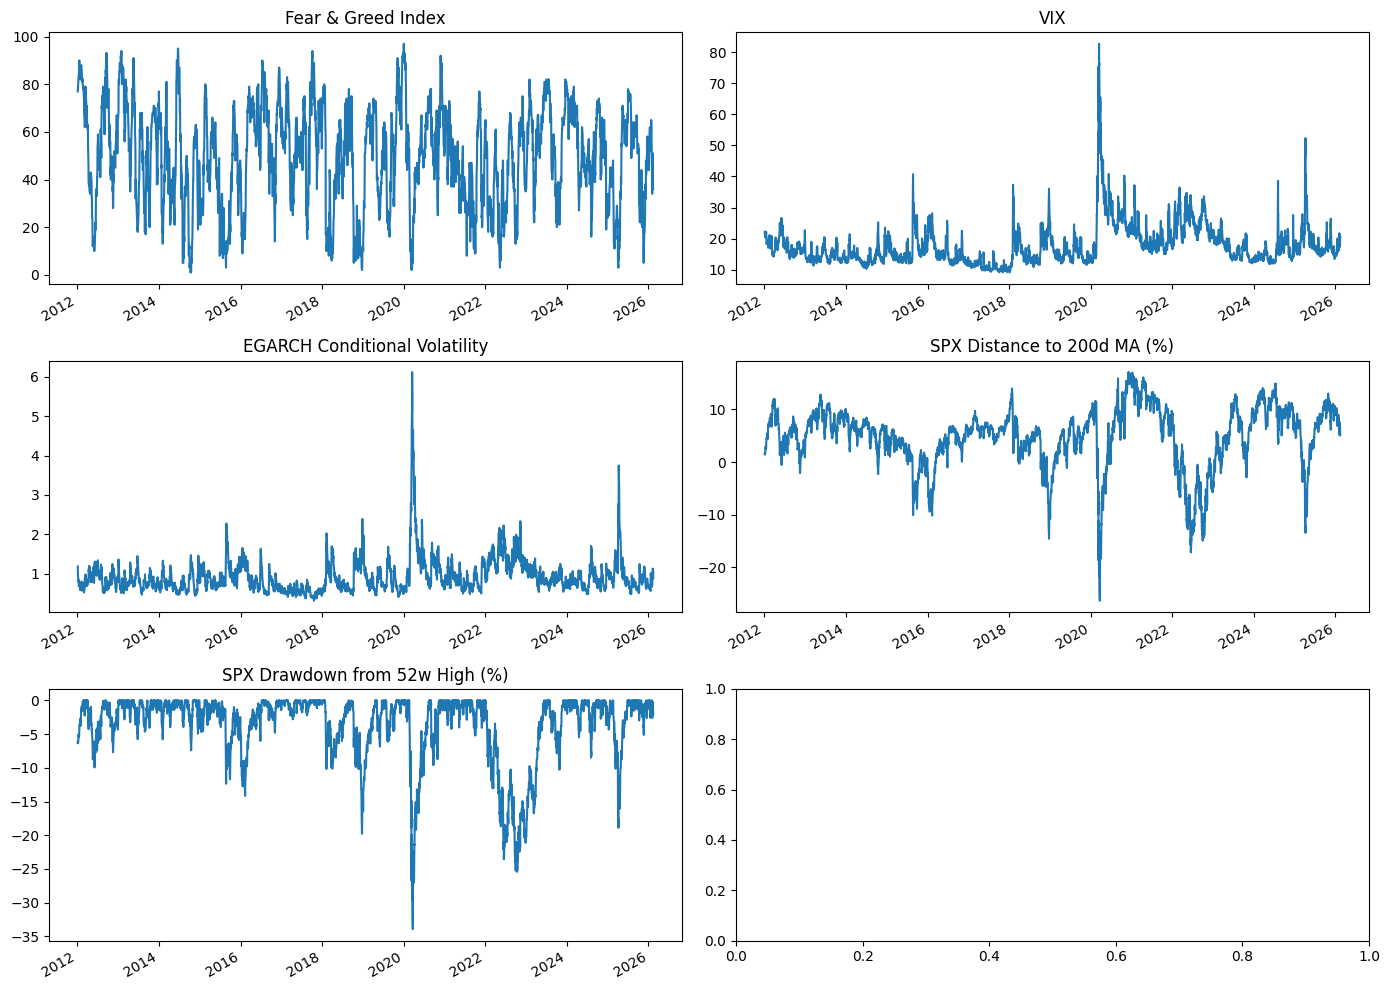

In [25]:
# Quick visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

market_state['fear_greed'].plot(ax=axes[0,0], title='Fear & Greed Index')
market_state['vix'].plot(ax=axes[0,1], title='VIX')
market_state['egarch_vol'].plot(ax=axes[1,0], title='EGARCH Conditional Volatility')
market_state['spx_dist_to_ma200'].plot(ax=axes[1,1], title='SPX Distance to 200d MA (%)')
market_state['spx_drawdown'].plot(ax=axes[2,0], title='SPX Drawdown from 52w High (%)')

plt.tight_layout()
plt.show()